# Exploratory Data Analysis — Users / Leads Dataset

**File:** `cleaned_users.csv`

This notebook looks at prospective plot buyers/leads — their demographics, budget, and
behavior — to understand what's related to whether someone actually purchased a plot.

Kept simple: basic pandas + seaborn only. Chart types are mixed on purpose (histogram,
boxplot, countplot, barplot, scatterplot, pie chart) instead of using one type for
everything.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)


In [2]:
users = pd.read_csv('../data/processed/cleaned_users.csv')
print("Shape:", users.shape)
users.head()

Shape: (12000, 25)


,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,Preferred_Plot_Size_SqFt,Preferred_Location,Distance_to_City_Center_km,Purpose,Loan_Required,Expected_Purchase_Timeline,Lead_Source,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value
0,CUST_20988,21,Male,Unknown,Mumbai,131500.0,1578000,2,Owned Flat/House,7020000.0,1500.0,Any,33.8,Self-use,No,1-3 years,Google & Social Media Ads,No,No,No,No,0.0639,Low,No,0
1,CUST_16662,29,Male,Real Estate & Construction,Kolkata,43800.0,525600,4,Owned Flat/House,2000000.0,600.0,Within City Limits,17.0,Self-use,Yes,1-3 years,Magicbricks / Real Estate Portal,Yes,No,No,No,0.0668,Low,No,0
2,CUST_10543,50,Male,Retail & Commerce,Noida,179000.0,2149200,2,Owned Flat/House,5710000.0,1200.0,Unknown,20.3,Investment,Yes,0-6 months,Channel Partner / Broker,No,Yes,Yes,Yes,0.9900,High,Yes,5550000
3,CUST_15741,44,Male,Retail & Commerce,Pune,45700.0,548400,4,Living with Parents,2300000.0,1000.0,Periphery / Growth Corridor,40.9,Self-use,Yes,6-12 months,Print / Newspaper Ad,Yes,No,No,No,0.2293,Low,No,0
4,CUST_16911,38,Male,Business Owner,Ahmedabad,219400.0,2632800,4,Rented,4730000.0,1500.0,Suburbs,22.8,Self-use,Yes,0-6 months,Magicbricks / Real Estate Portal,No,Yes,No,No,0.7678,High,Yes,8930000


In [5]:
users.describe()

,Age,Monthly_Income,Annual_Income,Family_Size,Plot_Budget,Preferred_Plot_Size_SqFt,Distance_to_City_Center_km,Purchase_Probability,Purchase_Value
count,12000.000000,1.200000e+04,1.200000e+04,12000.000000,1.200000e+04,12000.000000,12000.000000,12000.000000,1.200000e+04
mean,38.370583,1.368510e+05,1.662215e+06,3.486167,1.152012e+07,1297.245167,23.400392,0.416973,2.597596e+06
std,10.869871,1.108388e+05,1.309432e+06,1.110666,7.366500e+07,570.743048,11.003352,0.344886,4.434827e+06
min,18.000000,-4.847000e+05,3.360000e+05,1.000000,2.000000e+06,594.000000,2.500000,0.010000,0.000000e+00
25%,30.000000,6.400000e+04,7.812000e+05,3.000000,2.947500e+06,900.000000,15.600000,0.105275,0.000000e+00
50%,37.000000,1.070000e+05,1.296000e+06,4.000000,4.730000e+06,1200.000000,22.800000,0.288900,0.000000e+00
75%,44.000000,1.762000e+05,2.124000e+06,4.000000,7.490000e+06,1500.000000,29.500000,0.752650,3.942500e+06
max,70.000000,1.341500e+06,1.609800e+07,7.000000,1.000000e+09,4000.000000,48.000000,0.990000,4.735000e+07


In [ ]:
"""
users['Purchased_flag'] = users['Purchased'].map({'Yes': 1, 'No': 0})
users[['Purchased', 'Purchased_flag']].head()
"""

"users['Purchased_flag'] = users['Purchased'].map({'Yes': 1, 'No': 0})\nusers[['Purchased', 'Purchased_flag']].head()"

## 1. Purchased — class balance (pie chart)

Purchased
No     7176
Yes    4824
Name: count, dtype: int64


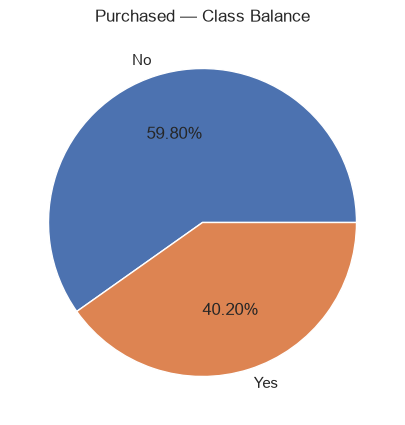

In [10]:
purchase_counts = users['Purchased'].value_counts()
print(purchase_counts)

plt.figure(figsize=(5, 5))
plt.pie(purchase_counts, labels=purchase_counts.index, autopct='%1.2f%%')
plt.title('Purchased — Class Balance')
plt.show()


## 2. Demographics: Age, Gender, Family size (histogram)

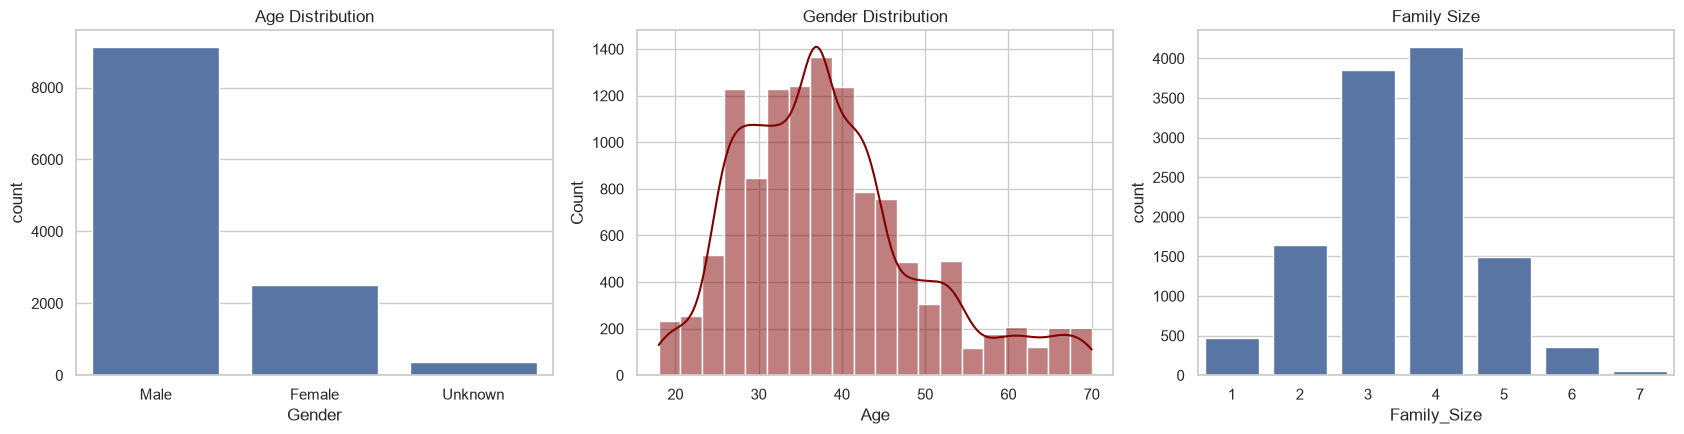

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Gender', ax=axes[0])
axes[1].set_title('Gender Distribution')

sns.histplot(users['Age'], bins=20, kde=True,color="maroon", ax=axes[1])
axes[0].set_title('Age Distribution')

sns.countplot(data=users, x='Family_Size', ax=axes[2])
axes[2].set_title('Family Size')
plt.savefig('../reports/figures/demographic_AGF.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 3. Income: Monthly (histogram) vs Annual (boxplot)

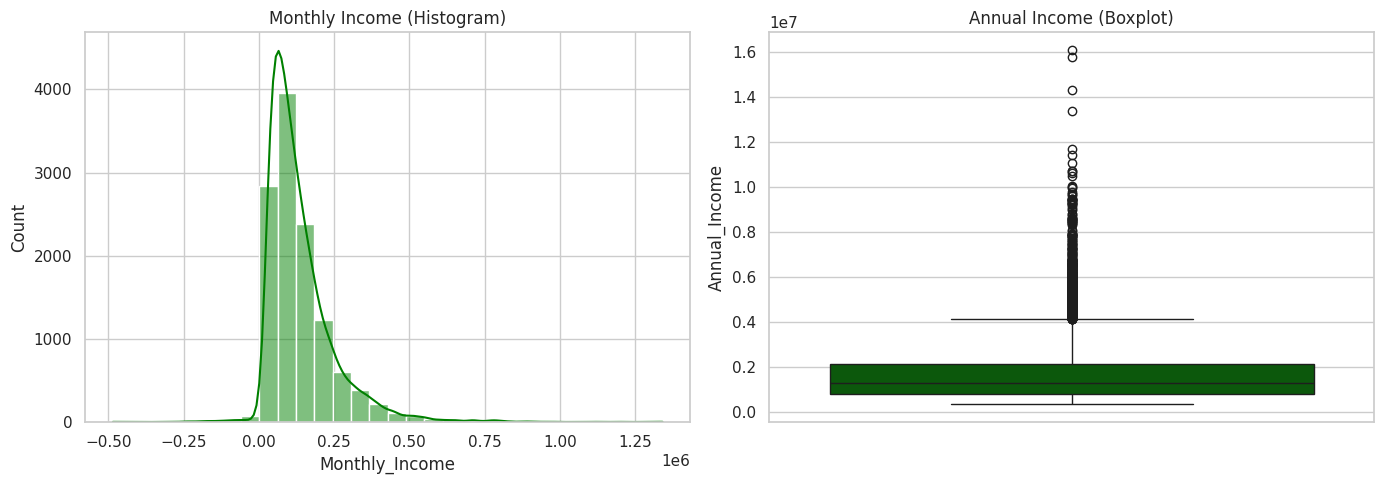

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Monthly_Income'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Monthly Income (Histogram)')

sns.boxplot(y=users['Annual_Income'], ax=axes[1], color='darkgreen')
axes[1].set_title('Annual Income (Boxplot)')

plt.tight_layout()
plt.show()


## 4. City-wise lead count (barplot)

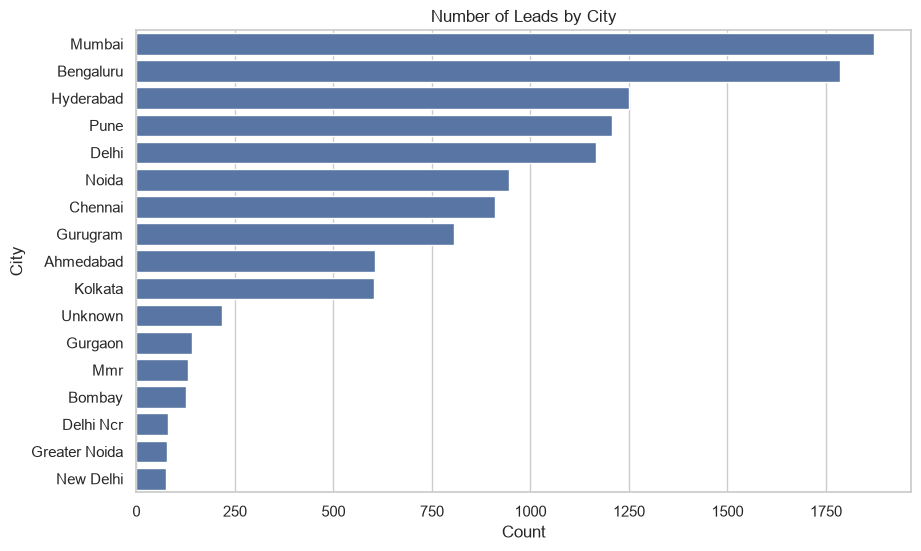

In [11]:
city_counts = users['City'].value_counts()
"""print(city_counts)"""

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Number of Leads by City')
plt.xlabel('Count')
plt.show()


## 5. Plot budget (histogram) & preferred plot size (boxplot)

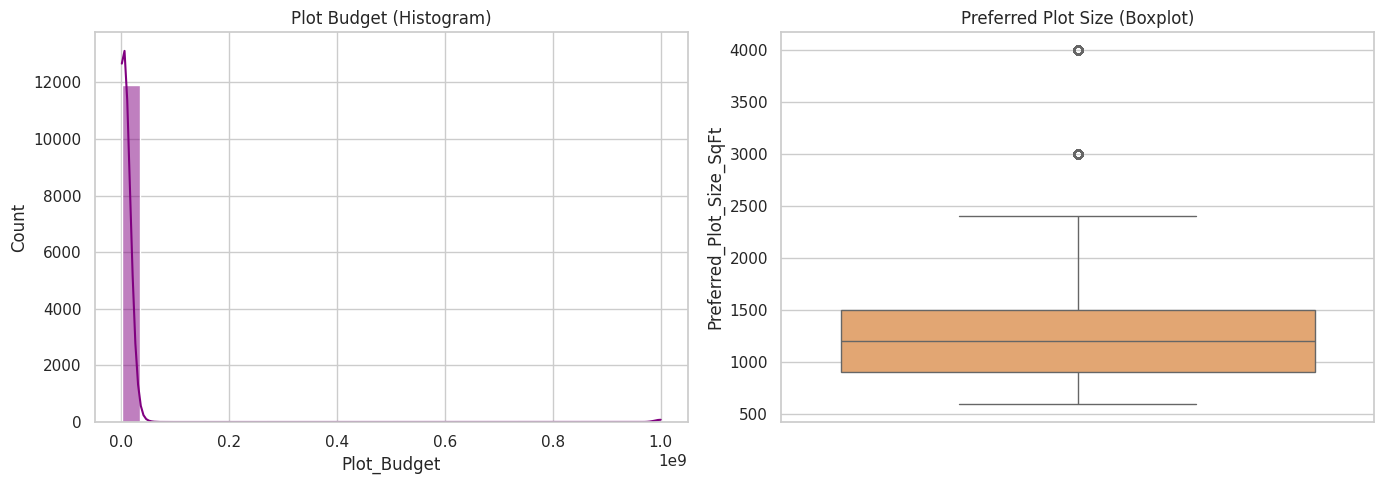

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Plot_Budget'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Plot Budget (Histogram)')

sns.boxplot(y=users['Preferred_Plot_Size_SqFt'], ax=axes[1], color='sandybrown')
axes[1].set_title('Preferred Plot Size (Boxplot)')

plt.tight_layout()
plt.show()


## 6. Loan requirement , Purpose & Purchase intent

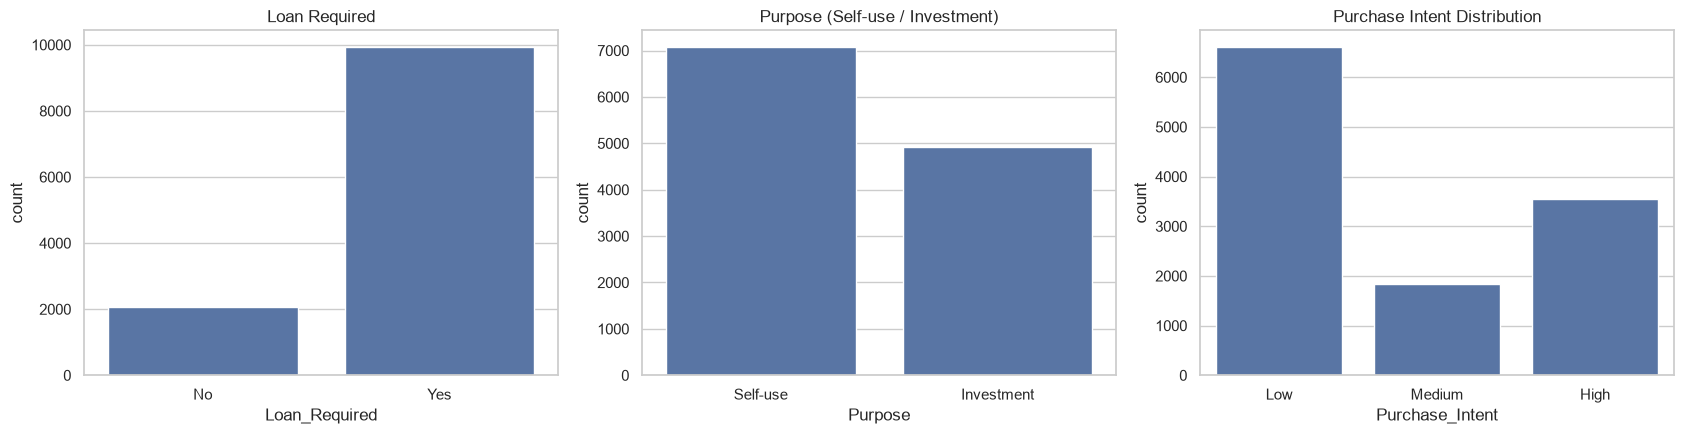

In [18]:
intent_counts = users['Purchase_Intent'].value_counts().reindex(['Low', 'Medium', 'High'])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Loan_Required', ax=axes[0])
axes[0].set_title('Loan Required')

sns.countplot(data=users, x='Purpose', ax=axes[1])
axes[1].set_title('Purpose (Self-use / Investment)')

sns.barplot(x=intent_counts.index ,y=intent_counts.values, ax=axes[2])
axes[2].set_title('Purchase Intent Distribution')
plt.ylabel('count')

plt.tight_layout()
plt.show()


## 7. Behavioral funnel vs Purchased (barplot)

For each behavioral step (previous enquiry, site visit, negotiation, booking), we check
what percentage of people who did "Yes" on that step actually purchased. Since
`Purchased_flag` is already 0/1, `groupby().mean()` directly gives us that percentage.


In [19]:
funnel_cols = ['Previous_Enquiry', 'Site_Visit', 'Negotiation_Done', 'Booking_Done']

for col in funnel_cols:
    conversion = users.groupby(col)['Purchased_flag'].mean() * 100
    print(f"--- {col} ---")
    print(conversion.round(1))
    print()


--- Previous_Enquiry ---
Previous_Enquiry
No     37.2
Yes    45.2
Name: Purchased_flag, dtype: float64

--- Site_Visit ---
Site_Visit
No     18.5
Yes    66.9
Name: Purchased_flag, dtype: float64

--- Negotiation_Done ---
Negotiation_Done
No     26.3
Yes    85.3
Name: Purchased_flag, dtype: float64

--- Booking_Done ---
Booking_Done
No     30.7
Yes    91.5
Name: Purchased_flag, dtype: float64



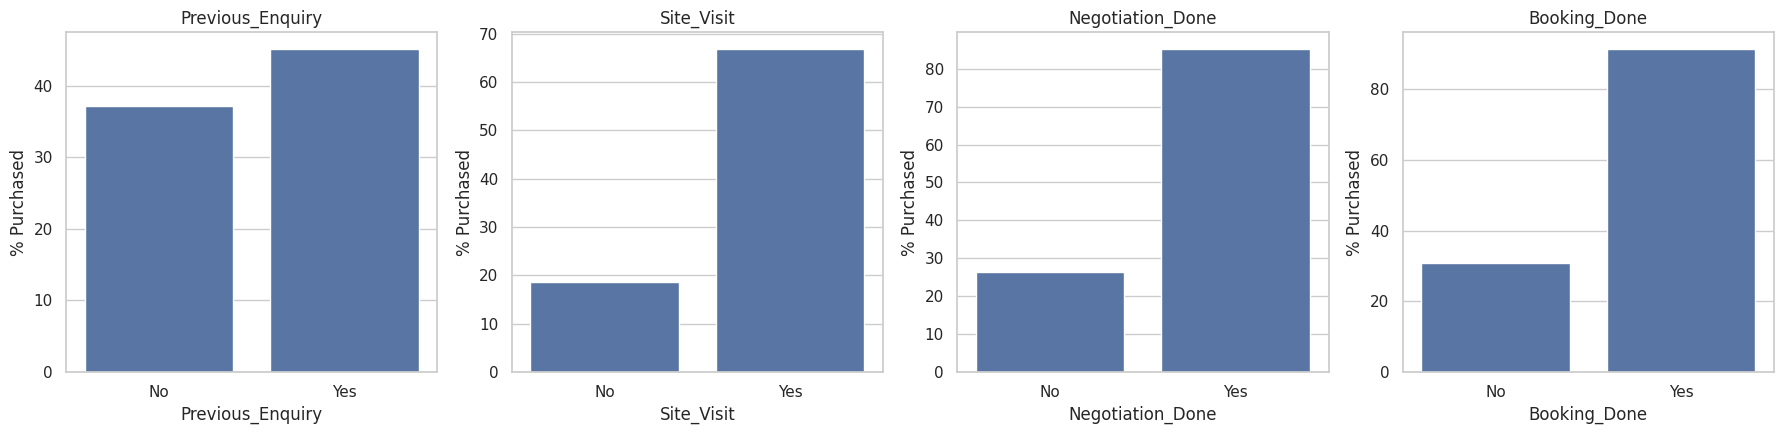

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, col in zip(axes, funnel_cols):
    conversion = users.groupby(col)['Purchased_flag'].mean() * 100
    sns.barplot(x=conversion.index, y=conversion.values, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('% Purchased')

plt.tight_layout()
plt.show()


## 8. Income vs Plot Budget relationship (scatterplot)

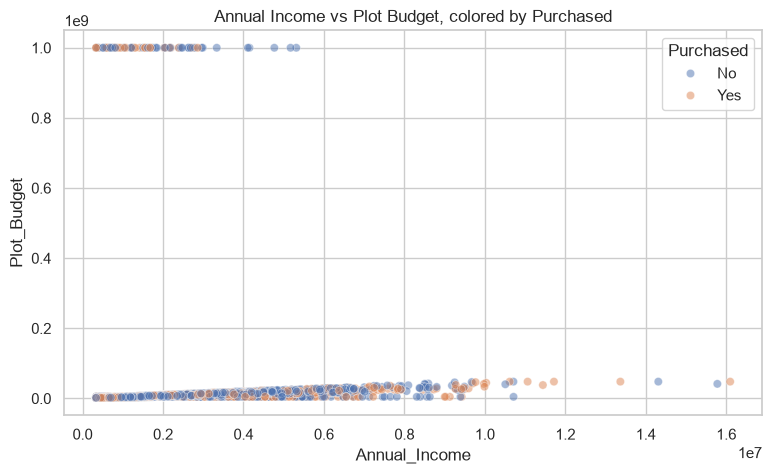

In [22]:
plt.figure()
sns.scatterplot(data=users, x='Annual_Income', y='Plot_Budget', hue='Purchased', alpha=0.5)
plt.title('Annual Income vs Plot Budget, colored by Purchased')
plt.show()


## 9. Occupation vs conversion (barplot)

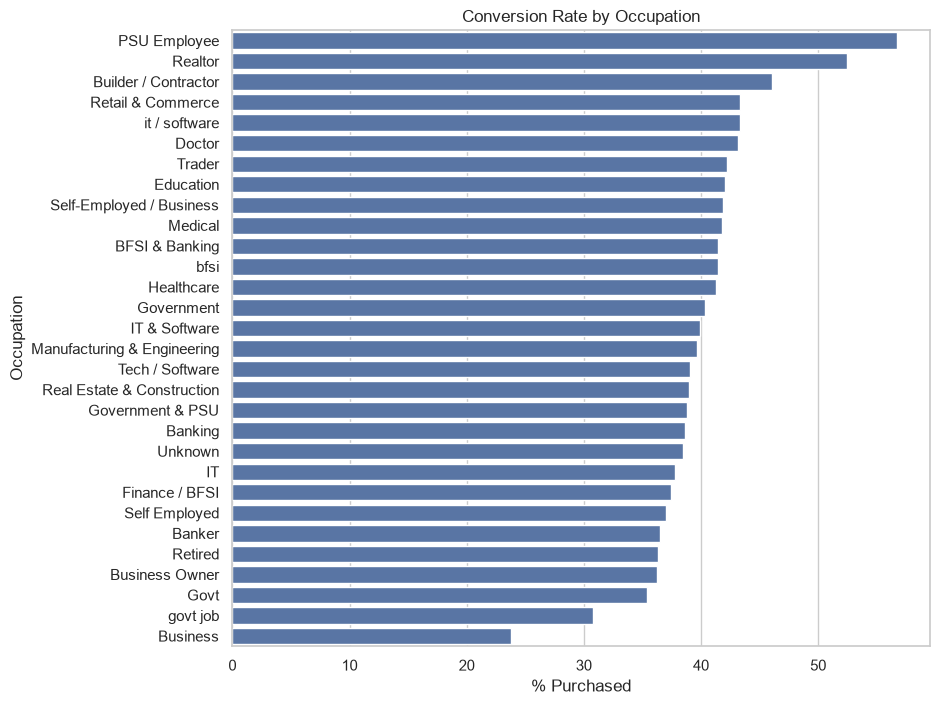

In [20]:
occupation_conversion = users.groupby('Occupation')['Purchased_flag'].mean().sort_values(ascending=False) * 100
"""print(occupation_conversion.round(1))"""

plt.figure(figsize=(9, 8))
sns.barplot(x=occupation_conversion.values, y=occupation_conversion.index)
plt.title('Conversion Rate by Occupation')
plt.xlabel('% Purchased')
plt.show()


## 10. Correlation heatmap (numeric features)

This is directly useful for linear regression: it shows which numeric columns move
together. Highly correlated features can cause multicollinearity, which is something
you'll want to watch out for once you start building models.


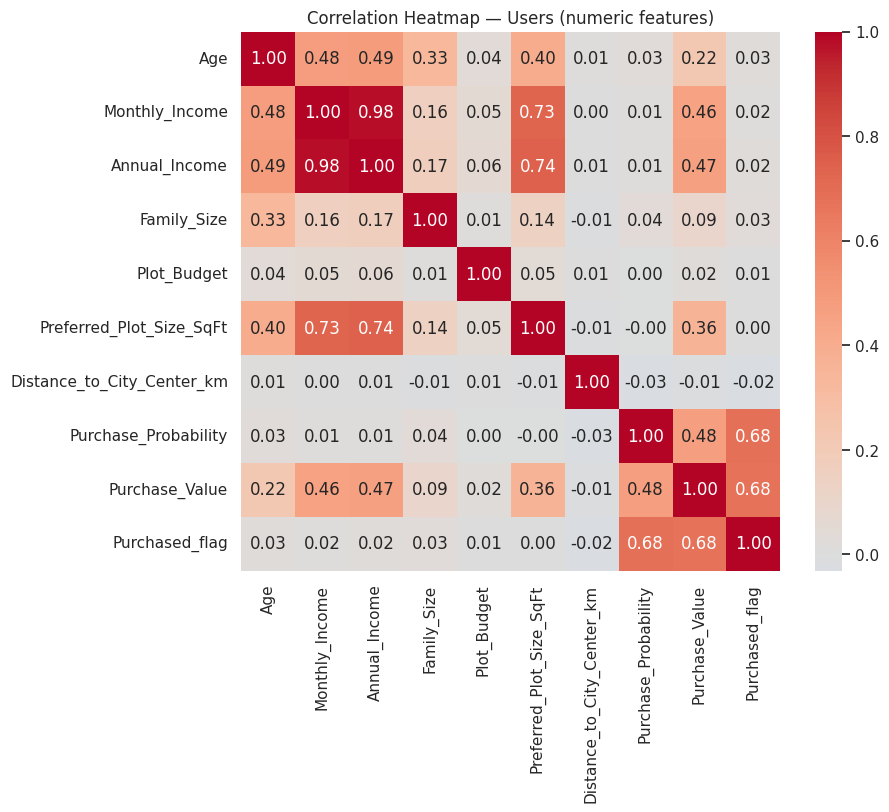

In [21]:
numeric_cols = users.select_dtypes(include='number').columns
corr = users[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Users (numeric features)')
plt.show()


---
## 17. Key Takeaways

1. **Class balance (`Purchased`)**
   > About **60% did not purchase, 40% did purchase**. Not extremely imbalanced, but worth
   > keeping in mind later.

2. **Behavioral funnel is the strongest signal**
   > Conversion rate increases a lot at each step: roughly **37% → 45%** with a previous
   > enquiry, **18% → 67%** with a site visit, **26% → 85%** after negotiation, and
   > **31% → 91%** after a booking. `Site_Visit` and `Negotiation_Done` look like the most
   > useful predictors in this dataset.

3. **Financial fields matter less than expected**
   > The Income vs Plot Budget scatterplot shows buyers (orange/blue dots) scattered across
   > the same range as non-buyers — no clear separation by income or budget alone. Median
   > plot budget is also almost identical for buyers and non-buyers. Behavior (funnel steps)
   > separates buyers from non-buyers far more than raw financial numbers do.

4. **Lead source doesn't differentiate much**
   > All lead sources convert in a narrow band (roughly 38%–41%) — the channel someone came
   > from isn't a strong predictor on its own.

5. **Occupation shows a wider spread**
   > Some occupations convert much higher (around 55%) than others (around 24–30%) —
   > occupation could be a useful category for a model.

**Takeaway for modelling:** behavioral columns (site visit, negotiation, booking, purchase
intent) look far more predictive of `Purchased` than demographic or income columns.
